In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [2]:
print("\n" + "="*60)
print("LOADING DATA FOR OMI ANALYSIS")
print("="*60)

tabla_ambientes = pd.read_csv('../data/raw/tabla_ambientes_RangoRep.csv')
print(f"✓ tabla_ambientes_RangoRep.csv: {tabla_ambientes.shape}")

nombres_df = pd.read_csv('../data/raw/nombres.csv')
nombres = nombres_df.iloc[:, 0].values
print(f"✓ nombres.csv: {len(nombres)} species")

presences = pd.read_csv('../data/raw/input_presences_OMI.csv')
print(f"✓ input_presences_OMI.csv: {presences.shape}")

pgls = pd.read_csv('../data/raw/input_pgls.csv')
print(f"✓ input_pgls.csv: {pgls.shape}")


LOADING DATA FOR OMI ANALYSIS
✓ tabla_ambientes_RangoRep.csv: (81393, 21)
✓ nombres.csv: 48 species
✓ input_presences_OMI.csv: (81393, 47)
✓ input_pgls.csv: (47, 17)


In [3]:
print("\n" + "="*60)
print("DATA ALIGNMENT CHECK")
print("="*60)

print(f"\nTabla_ambientes: {tabla_ambientes.shape}")
print(f"Presences: {presences.shape}")
print(f"Species: {len(nombres)}")

if tabla_ambientes.shape[0] == presences.shape[0]:
    print(f"✓ Alignment OK: {tabla_ambientes.shape[0]} rows match")
else:
    print(f"✗ ERROR: Mismatch in row count")


DATA ALIGNMENT CHECK

Tabla_ambientes: (81393, 21)
Presences: (81393, 47)
Species: 48
✓ Alignment OK: 81393 rows match


In [4]:
print("\n" + "="*60)
print("SELECT ENVIRONMENTAL VARIABLES (columns 3, 6, 9)")
print("="*60)

# Python 0-based: indices 2, 5, 8
env_cols_indices = [2, 5, 8]
env_data = tabla_ambientes.iloc[:, env_cols_indices].copy()

print(f"Selected columns: {tabla_ambientes.columns[env_cols_indices].tolist()}")
print(f"Shape: {env_data.shape}")
print(f"\nFirst 5 rows:")
print(env_data.head())

print(f"\nDescriptive statistics:")
print(env_data.describe())


SELECT ENVIRONMENTAL VARIABLES (columns 3, 6, 9)
Selected columns: ['bio_1', 'bio_12', 'bio_15']
Shape: (81393, 3)

First 5 rows:
   bio_1  bio_12  bio_15
0  -10.3     108      75
1  -10.4     111      75
2  -10.4     115      73
3  -10.5     120      72
4  -10.4     116      72

Descriptive statistics:
             bio_1        bio_12        bio_15
count  81393.00000  81393.000000  81393.000000
mean       3.40897    641.857445     45.841018
std        8.47884    429.358425     20.432384
min      -17.90000     57.000000      5.000000
25%       -3.10000    349.000000     30.000000
50%        2.10000    502.000000     48.000000
75%        9.40000    856.000000     58.000000
max       26.80000   5229.000000    123.000000


In [5]:
print("\n" + "="*60)
print("PCA ANALYSIS")
print("="*60)

# Standardize
scaler = StandardScaler()
env_scaled = scaler.fit_transform(env_data)

print(f"Standardized (mean ≈ 0, std ≈ 1):")
print(f"  Mean: {env_scaled.mean(axis=0)}")
print(f"  Std: {env_scaled.std(axis=0)}")

# PCA
n_components = 3
pca = PCA(n_components=n_components)
pca_scores = pca.fit_transform(env_scaled)

print(f"\nPCA Results:")
print(f"  Explained variance: {pca.explained_variance_ratio_}")
print(f"  Cumulative: {np.cumsum(pca.explained_variance_ratio_)}")
print(f"  Total: {np.sum(pca.explained_variance_ratio_):.2%}")

# Create dataframe (dudi1$li in R)
pca_li = pd.DataFrame(pca_scores, columns=['Axis1', 'Axis2', 'Axis3'])

print(f"\nPCA scores shape: {pca_li.shape}")
print(pca_li.head())


PCA ANALYSIS
Standardized (mean ≈ 0, std ≈ 1):
  Mean: [-8.93929160e-17 -8.93929160e-17  1.34089374e-16]
  Std: [1. 1. 1.]

PCA Results:
  Explained variance: [0.5517123  0.27514982 0.17313789]
  Cumulative: [0.5517123  0.82686211 1.        ]
  Total: 100.00%

PCA scores shape: (81393, 3)
      Axis1     Axis2     Axis3
0 -2.434530 -0.323752  0.406350
1 -2.435918 -0.333779  0.415594
2 -2.373902 -0.393100  0.367603
3 -2.344282 -0.432788  0.352851
4 -2.344406 -0.422551  0.341847


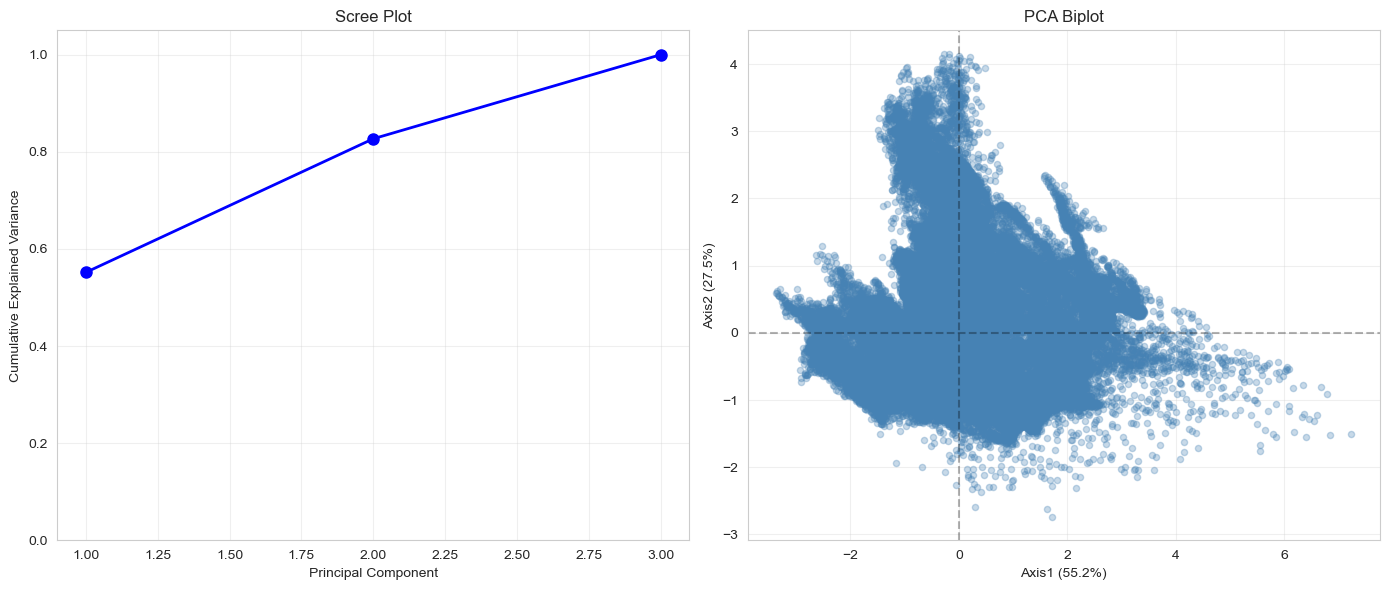

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scree plot
axes[0].plot(range(1, n_components+1), 
             np.cumsum(pca.explained_variance_ratio_), 
             'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Biplot
axes[1].scatter(pca_li['Axis1'], pca_li['Axis2'], 
                alpha=0.3, s=20, color='steelblue')
axes[1].set_xlabel(f"Axis1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"Axis2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title('PCA Biplot')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("\n" + "="*60)
print("CALCULATE NICHE METRICS (NP & NB)")
print("="*60)

niche_metrics = []

for i, sp_name in enumerate(nombres):
    if i < presences.shape[1]:
        pres_col = presences.iloc[:, i].values
        present_mask = pres_col > 0
        present_pca = pca_li.values[present_mask]
        
        if len(present_pca) > 0:
            # Niche Position: mean in PCA space
            np_axis1 = present_pca[:, 0].mean()
            np_axis2 = present_pca[:, 1].mean()
            np_axis3 = present_pca[:, 2].mean()
            
            # Niche Breadth: variance of distances from center
            center = present_pca.mean(axis=0)
            distances = np.linalg.norm(present_pca - center, axis=1)
            nb = np.var(distances)
            
            niche_metrics.append({
                'Species': sp_name,
                'NP_Axis1': np_axis1,
                'NP_Axis2': np_axis2,
                'NP_Axis3': np_axis3,
                'NB': nb,
                'n_presences': len(present_pca)
            })

niche_df = pd.DataFrame(niche_metrics)

print(f"Calculated for {len(niche_df)} species")
print(f"\nFirst 10:")
print(niche_df.head(10))

print(f"\nSummary:")
print(niche_df[['NP_Axis1', 'NP_Axis2', 'NP_Axis3', 'NB']].describe())


CALCULATE NICHE METRICS (NP & NB)
Calculated for 47 species

First 10:
                   Species  NP_Axis1  NP_Axis2  NP_Axis3        NB  \
0    Cardellina_canadensis  1.149219 -0.545324 -0.156556  0.235690   
1       Cardellina_pusilla  0.527059 -0.085963  0.367796  0.682942   
2    Cardellina_rubrifrons -0.235819  1.776292  0.230880  0.235985   
3       Geothlypis_formosa  2.269406  0.137653 -0.220035  0.087355   
4  Geothlypis_philadelphia  0.874317 -0.436062 -0.122243  0.181662   
5       Geothlypis_tolmiei  0.433909  0.159025 -0.006529  0.700797   
6       Geothlypis_trichas  1.095728  0.005151 -0.196868  0.305502   
7   Helmitheros_vermivorum  2.309086 -0.030944 -0.255943  0.061201   
8       Leiothlypis_celata  0.157767  0.035959 -0.019369  0.779280   
9       Leiothlypis_luciae -0.054329  1.928536 -0.823904  0.180676   

   n_presences  
0         2503  
1         2137  
2          163  
3         2110  
4         2988  
5         2438  
6         5361  
7         1476  
8   

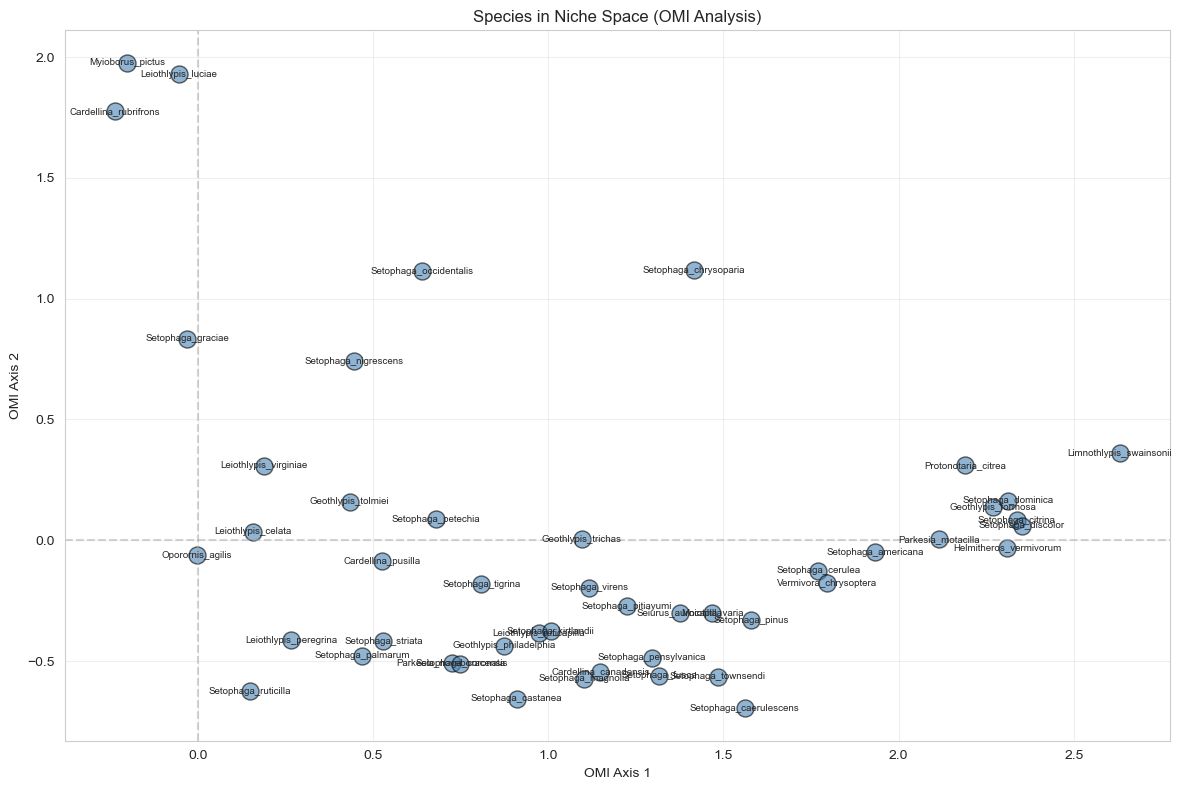

In [8]:
# Plot species in OMI niche space
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(niche_df['NP_Axis1'], niche_df['NP_Axis2'],
                     s=150, alpha=0.6, color='steelblue', 
                     edgecolors='black', linewidth=1)

# Add labels
for idx, row in niche_df.iterrows():
    ax.annotate(row['Species'], 
               xy=(row['NP_Axis1'], row['NP_Axis2']),
               fontsize=7, ha='center', va='center')

# Reference lines
ax.axhline(y=0, color='darkgrey', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='darkgrey', linestyle='--', alpha=0.5)

ax.set_xlabel('OMI Axis 1')
ax.set_ylabel('OMI Axis 2')
ax.set_title('Species in Niche Space (OMI Analysis)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


STATISTICAL TESTS: NP vs NB

Correlation NP_Axis1 vs NB:
  Pearson:  r=-0.4314, p=0.0025
  Spearman: ρ=-0.5937, p=0.0000


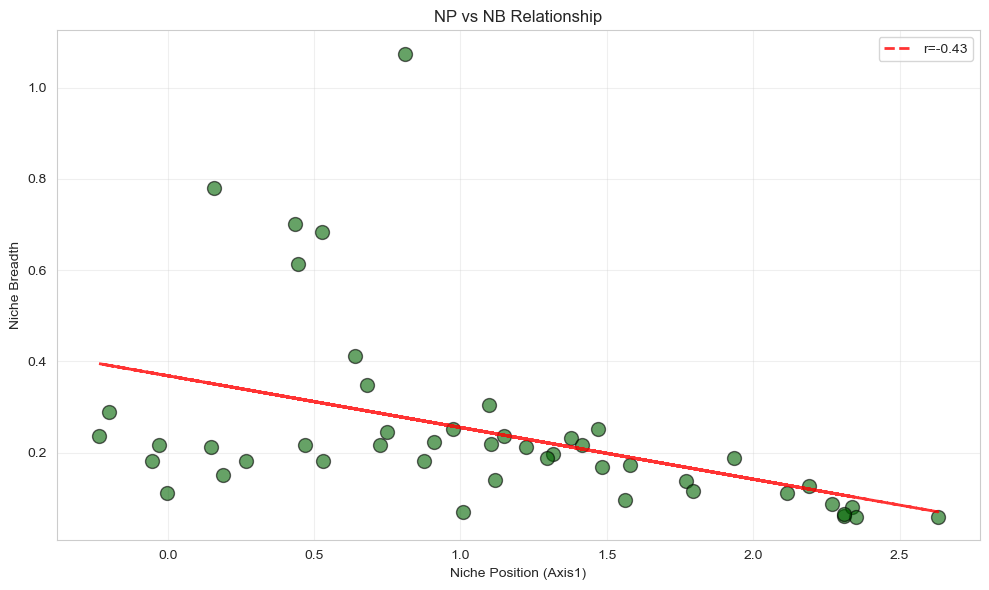

In [9]:
print("\n" + "="*60)
print("STATISTICAL TESTS: NP vs NB")
print("="*60)

# Correlation
corr_pearson, p_pearson = stats.pearsonr(niche_df['NP_Axis1'], niche_df['NB'])
corr_spearman, p_spearman = stats.spearmanr(niche_df['NP_Axis1'], niche_df['NB'])

print(f"\nCorrelation NP_Axis1 vs NB:")
print(f"  Pearson:  r={corr_pearson:.4f}, p={p_pearson:.4f}")
print(f"  Spearman: ρ={corr_spearman:.4f}, p={p_spearman:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(niche_df['NP_Axis1'], niche_df['NB'],
          s=100, alpha=0.6, color='darkgreen', edgecolors='black', linewidth=1)

# Regression line
z = np.polyfit(niche_df['NP_Axis1'], niche_df['NB'], 1)
p = np.poly1d(z)
ax.plot(niche_df['NP_Axis1'], p(niche_df['NP_Axis1']), 
        "r--", alpha=0.8, linewidth=2, label=f'r={corr_pearson:.2f}')

ax.set_xlabel('Niche Position (Axis1)')
ax.set_ylabel('Niche Breadth')
ax.set_title('NP vs NB Relationship')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
import os

os.makedirs('../data/processed', exist_ok=True)

niche_df.to_csv('../data/processed/niche_metrics.csv', index=False)
print(f"✓ Saved: ../data/processed/niche_metrics.csv")

pca_li.to_csv('../data/processed/pca_scores.csv', index=False)
print(f"✓ Saved: ../data/processed/pca_scores.csv")

✓ Saved: ../data/processed/niche_metrics.csv
✓ Saved: ../data/processed/pca_scores.csv


In [11]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"\n✓ Study Design:")
print(f"  - Species: {len(nombres)} Parulidae")
print(f"  - Area: {tabla_ambientes.shape[0]} breeding range cells")
print(f"  - Variables: 3 environmental (columns 3, 6, 9)")

print(f"\n✓ PCA Results:")
print(f"  - Variance explained: {np.sum(pca.explained_variance_ratio_):.2%}")

print(f"\n✓ Niche Metrics:")
print(f"  - NP range: {niche_df['NP_Axis1'].min():.2f} to {niche_df['NP_Axis1'].max():.2f}")
print(f"  - NB range: {niche_df['NB'].min():.2f} to {niche_df['NB'].max():.2f}")

print(f"\n✓ NP-NB Relationship: r={corr_pearson:.4f}, p={p_pearson:.4f}")

print("\nNotebook 02 COMPLETE ✓")


ANALYSIS SUMMARY

✓ Study Design:
  - Species: 48 Parulidae
  - Area: 81393 breeding range cells
  - Variables: 3 environmental (columns 3, 6, 9)

✓ PCA Results:
  - Variance explained: 100.00%

✓ Niche Metrics:
  - NP range: -0.24 to 2.63
  - NB range: 0.06 to 1.07

✓ NP-NB Relationship: r=-0.4314, p=0.0025

Notebook 02 COMPLETE ✓
